# [1.3.1] Linear probes ④ — 인과 개입: 그 방향을 밀면 판단이 바뀌는가

①~③은 모두 **관찰**이다. 아무리 잘 읽히고 잘 전이되어도 "모델이 그 정보를 쓴다"(A7의 반대)는 관찰만으로 나오지 않는다. 모델이 쓰지 않는 성질도 선형으로 읽힌다(Ravichander et al. 2021).

선형 표현 가설이 주는 무기가 여기서 쓰인다. 진실이 방향 $\theta$로 표현되고 모델이 그 방향을 읽어 답을 낸다면,

> activation에 $+\alpha\theta$를 더하면 거짓 문장에도 "TRUE"라고 답하고, $-\alpha\theta$를 더하면 참 문장에도 "FALSE"라고 답해야 한다.

*Geometry of Truth*의 §5가 바로 이 실험이고, 원본 ARENA §3이 이를 재현한다. 이 notebook은 같은 실험을 하되 저자가 반드시 붙여야 할 대조군을 함께 붙인다.

## 개입이 증거가 되려면 — 미리 정하는 네 가지 기준

1. **특이성:** 같은 크기의 **무작위 방향**은 같은 효과를 내지 않아야 한다. 그렇지 않으면 "아무 방향이나 크게 흔들면 판단이 무너진다"로 설명된다.
2. **용량–반응:** 효과가 세기 $\alpha$에 따라 단조롭게 커져야 한다.
3. **양방향:** 더하면 F→T, 빼면 T→F. 한쪽만 되면 "기본값으로 무너진다"로 설명될 수 있다.
4. **모델이 망가지지 않음:** $P(\text{TRUE}) + P(\text{FALSE})$가 1 근처에 남아야 한다. 이게 무너지면 판단을 바꾼 게 아니라 출력 분포를 깨뜨린 것이다.

## 학습 목표, 필수 경로, stop rule

1. 행동 측정($P(\text{TRUE})-P(\text{FALSE})$)과 개입 hook을 구현한다.
2. GoT 방식의 개입을 재현하고, **같은 norm의 무작위 방향 대조군**이 결론을 어떻게 바꾸는지 본다.
3. 용량–반응 곡선에서 "특이적인 구간"을 찾는다.
4. MM 방향과 LR 방향의 인과 효과가 왜 다른지 ①의 toy와 연결한다.

### ⑤로 넘어가도 되는 기준

- "probe 방향을 더했더니 FALSE가 TRUE로 바뀌었다"는 결과에 무작위 방향 대조군이 없으면 왜 약한지 말할 수 있다.
- 이 개입이 보이는 것이 **충분성**(밀면 바뀐다)이지 **필요성**(없으면 못 한다)은 아니라는 것을 구분한다(필요성은 ⑦).

## 공통 setup

#### Cell 01 · 실행 환경과 공통 import

- **이번 셀의 질문:** 환경이 같은가?
- **출력에서 볼 것:** 버전과 GPU를 확인한다.
- **해석 범위:** 환경 확인만 한다.
- **다음 단계의 목적:** 모델과 ①의 split, probe 층을 재현한다.

In [1]:
# 공통 setup — import는 이 셀 한 곳에서만 한다.
from __future__ import annotations

import gc
import sys
from importlib.metadata import version
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():  # 저장소 root 등 다른 위치에서 연 경우
    HERE = next(
        p
        for p in [HERE / "chapter1_transformer_interp/exercises/part31_linear_probes_ko", *HERE.parents]
        if (p / "probe_lab.py").exists()
    )
sys.path.insert(0, str(HERE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import probe_lab as pl
import tests

pl.use_style()
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

print({
    "torch": torch.__version__,
    "transformers": version("transformers"),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "model": pl.DEFAULT_MODEL,
})

{'torch': '2.11.0+cu128', 'transformers': '5.18.0', 'gpu': 'NVIDIA RTX A6000', 'model': 'meta-llama/Llama-3.1-8B-Instruct'}


#### Cell 02 · 모델, split, probe 방향

- **이번 셀의 질문:** 개입에 쓸 방향을 어디서 얻는가?
- **출력에서 볼 것:** layer 12 MM 방향 θ의 norm(= train 두 평균 사이 거리)과 MM·LR의 cosine(0.49)을 본다.
- **해석 범위:** 방향은 **train 도시**로만 계산한다. 개입 효과는 test 도시(298문장)에서 잰다.
- **다음 단계의 목적:** 모델의 판단을 재는 행동 측정을 만든다.

In [2]:
model, tok = pl.load_model(pl.DEFAULT_MODEL)
store = pl.ActivationStore(model=model, tokenizer=tok)
N_LAYERS = len(pl.decoder_layers(model))
print({"layers": N_LAYERS, "d_model": model.config.hidden_size,
       "dtype": str(next(model.parameters()).dtype),
       "GPU GiB": round(torch.cuda.memory_allocated() / 2**30, 1) if torch.cuda.is_available() else None})

cities = pl.load_dataset("cities")
y = cities["label"].to_numpy()
split = pl.group_split(cities["group"].to_numpy(), seed=0)
tr, te = split.train, split.test
PROBE_LAYER = pl.load_results("01_observation")["probe_layer"]
X = store.dataset("cities", [PROBE_LAYER])[PROBE_LAYER]
mm = pl.fit_mass_mean(X[tr], y[tr])
lr = pl.fit_logistic(X[tr], y[tr], C=0.1)
SCALE = float(np.linalg.norm(mm.direction))   # ||μ₁ − μ₀|| : '평균 하나만큼' 미는 크기
print({"PROBE_LAYER": PROBE_LAYER, "||mu1 - mu0||": round(SCALE, 2), "cos(MM, LR)": round(pl.cosine(mm.direction, lr.direction), 3)})

{'layers': 32, 'd_model': 4096, 'dtype': 'torch.bfloat16', 'GPU GiB': 15.0}


{'PROBE_LAYER': 12, '||mu1 - mu0||': 4.49, 'cos(MM, LR)': 0.491}


# 1️⃣ 행동 측정

few-shot prompt 뒤에 문장과 ` This statement is:`를 붙이고, 다음 token 분포에서

$$m(x) = P(\text{ TRUE}) - P(\text{ FALSE})$$

를 잰다. $m > 0$이면 모델이 "TRUE"라고 답하는 것으로 본다.

### ✏️ Exercise 6 · `true_false_margin` 구현

> 난이도 🔴🔴⚪⚪⚪ · 중요도 🔵🔵🔵🔵⚪ · 15분

- 답 token은 `" TRUE"`, `" FALSE"`(**앞 공백 포함**)가 한 token인지 먼저 확인한다. 공백 없는 `"TRUE"`는 다른 token이다.
- right padding이므로 각 행의 마지막 유효 위치의 logits를 읽는다.
- 반환: `[N]` numpy, $P(\text{TRUE}) - P(\text{FALSE})$

In [3]:
# Scratch
MY_IMPL = False

@torch.inference_mode()
def my_true_false_margin(model, tokenizer, prompts) -> np.ndarray:
    raise NotImplementedError

if MY_IMPL:
    tests.test_true_false_margin(my_true_false_margin, model, tok)

#### Cell 03 · Reference 구현과 기준선(개입 없음)

- **이번 셀의 질문:** 개입 전에 모델은 test 문장들을 얼마나 확신 있게 판정하는가?
- **출력에서 볼 것:** 저장된 출력: 참 문장 평균 m ≈ +0.99, 거짓 문장 평균 m ≈ −0.99, 행동 정확도 1.000, P(TRUE)+P(FALSE) ≈ 0.998. 테스트 ✅.
- **해석 범위:** 기준선이 양끝에 붙어 있으므로 개입 효과는 '얼마나 반대쪽으로 넘어가는가'로 읽힌다. 뒤집힘 비율(flip rate)도 함께 본다.
- **다음 단계의 목적:** 개입할 위치를 정하고 hook을 만든다.

In [4]:
@torch.inference_mode()
def true_false_margin_reference(model, tokenizer, prompts, batch_size: int = 32) -> np.ndarray:
    t_id, f_id = pl.answer_token_ids(tokenizer)          # ' TRUE', ' FALSE'가 각각 한 token인지 확인
    device = next(model.parameters()).device
    out = []
    for s in range(0, len(prompts), batch_size):
        enc = tokenizer(list(prompts[s : s + batch_size]), return_tensors="pt", padding=True).to(device)
        last = enc["attention_mask"].sum(1) - 1
        probs = model(**enc).logits[torch.arange(len(last), device=device), last].float().softmax(-1)
        out.append((probs[:, t_id] - probs[:, f_id]).cpu())
    return torch.cat(out).numpy()


tests.test_true_false_margin(true_false_margin_reference, model, tok)
prompts = pl.build_prompts(cities["statement"].tolist())
P_test, y_test = [prompts[i] for i in te], y[te]
base = pl.true_false_margin(model, tok, P_test)
print({"mean m | true": round(float(base["p_diff"][y_test == 1].mean()), 3),
       "mean m | false": round(float(base["p_diff"][y_test == 0].mean()), 3),
       "behavior acc": pl.accuracy(y_test, base["p_diff"]),
       "mean P(TRUE)+P(FALSE)": round(float(base["p_sum"].mean()), 3)})

✅ true_false_margin: [ 0.997 -0.998]


{'mean m | true': 0.99, 'mean m | false': -0.994, 'behavior acc': 1.0, 'mean P(TRUE)+P(FALSE)': 0.998}


# 2️⃣ 개입 설계 — Geometry of Truth 방식

GoT의 설정을 이 모델에 옮긴다.

- **방향:** layer 12 MM 방향의 단위벡터 $\hat\theta$.
- **크기:** $\alpha \cdot \|\mu_1 - \mu_0\|$. $\alpha=1$이면 "거짓 평균을 참 평균까지 옮기는 거리"만큼 민다.
- **위치:** 문장의 마지막 단어 token과 마침표 token(GoT가 쓴 두 위치). `This statement is:` 이후는 건드리지 않는다.
- **층:** layer 8–12의 **모든** block 출력에 더한다(GoT: 13B에서 `intervene_layer=8`부터 `probe_layer=14`까지). residual stream은 다음 층으로 이어지므로 여러 층에 더한 벡터는 **누적**된다. 이 점은 4️⃣에서 다시 본다.

### ✏️ Exercise 7 · 위치 지정 steering hook

> 난이도 🔴🔴🔴⚪⚪ · 중요도 🔵🔵🔵🔵🔵 · 20~30분

block $\ell$의 forward hook에서 출력 `h: [B, S, D]`를 받아, 각 행의 지정 위치들에만 `vec: [D]`를 더한 새 tensor를 반환한다. right padding이라 위치는 행마다 다르다(`last - k`). 반환값을 돌려주는 hook은 출력을 **교체**한다(1.2의 개입 hook과 같다). `try/finally`로 hook을 반드시 제거한다.

In [5]:
# Scratch — pl.add_to_residual 과 같은 일을 하는 context manager를 직접 만들어 본다.
def my_add_hook(vec: torch.Tensor, positions_from_end: tuple[int, ...], last: torch.Tensor):
    """register_forward_hook에 넘길 hook 함수를 돌려준다."""
    raise NotImplementedError

#### Cell 04 · 개입 위치 확인과 α=0 sanity check

- **이번 셀의 질문:** hook이 정말 문장의 마지막 단어와 마침표에 붙는가? 아무것도 더하지 않으면 결과가 기준선과 같은가?
- **출력에서 볼 것:** token 목록 끝에서 마침표 `.`과 그 앞 token이 개입 위치로 표시되는지 본다(저장된 출력의 첫 문장은 `Côte d'Ivoire.`라서 앞 token이 `ire`다). α=0 개입의 결과가 기준선과 완전히 같다는 assert가 통과해야 한다.
- **해석 범위:** α=0 검사는 hook 자체가 계산을 바꾸지 않는다는 것만 확인한다. `probe_lab.true_false_margin(vectors=..., positions_from_end=...)`이 Exercise 7의 hook을 감싼 reference다.
- **다음 단계의 목적:** GoT 설정(α=1)으로 개입한다.

In [6]:
K_POS = pl.suffix_positions(tok)     # (끝에서 마지막 단어까지 거리, 끝에서 마침표까지 거리)
ids = tok(P_test[0])["input_ids"]
toks = tok.convert_ids_to_tokens(ids)
print("prompt 끝 token들:", toks[-8:])
print("개입 위치:", [toks[len(ids) - 1 - k] for k in K_POS])

INTERVENE_LAYERS = list(range(8, PROBE_LAYER + 1))
u_mm = torch.tensor(mm.unit, dtype=torch.float32)
u_lr = torch.tensor(lr.unit, dtype=torch.float32)


def run(direction: torch.Tensor, alpha: float, layers=INTERVENE_LAYERS, prompts_=P_test) -> dict[str, np.ndarray]:
    vecs = {l: alpha * SCALE * direction for l in layers}
    return pl.true_false_margin(model, tok, prompts_, vectors=vecs, positions_from_end=K_POS)


zero = run(u_mm, 0.0)
assert np.allclose(zero["p_diff"], base["p_diff"], atol=1e-6)
print("α=0 개입 = 기준선 ✅")

prompt 끝 token들: ["'I", 'vo', 'ire', '.', 'ĠThis', 'Ġstatement', 'Ġis', ':']
개입 위치: ['ire', '.']


α=0 개입 = 기준선 ✅


#### Cell 05 · GoT 설정 그대로: α=1, MM 방향

- **이번 셀의 질문:** θ를 더하면 거짓 문장에 TRUE라고 답하고, 빼면 참 문장에 FALSE라고 답하는가?
- **출력에서 볼 것:** 저장된 출력: 더하기 → 거짓 문장 평균 m이 −0.99에서 +0.73으로, 92%가 TRUE로 뒤집힌다. 빼기 → 참 문장 평균 m이 +0.99에서 −0.99로, 100%가 FALSE로 뒤집힌다. P(TRUE)+P(FALSE)는 0.99로 유지된다.
- **해석 범위:** 여기서 멈추면 GoT의 결론('진실 방향은 인과적으로 관여한다')을 그대로 재현한 것처럼 보인다. 하지만 아직 대조군이 없다.
- **다음 단계의 목적:** 같은 norm의 무작위 방향 20개로 같은 개입을 한다.

In [7]:
def summarize(r: dict[str, np.ndarray], name: str) -> dict:
    return {"direction": name,
            "F→T: mean m on false (add)": float(r["add"]["p_diff"][y_test == 0].mean()),
            "F→T flip rate": float(np.mean(r["add"]["p_diff"][y_test == 0] > 0)),
            "T→F: mean m on true (subtract)": float(r["sub"]["p_diff"][y_test == 1].mean()),
            "T→F flip rate": float(np.mean(r["sub"]["p_diff"][y_test == 1] < 0)),
            "P(T)+P(F)": float(np.mean([r["add"]["p_sum"].mean(), r["sub"]["p_sum"].mean()]))}


got = {"add": run(u_mm, 1.0), "sub": run(u_mm, -1.0)}
display(pd.DataFrame([summarize(got, "MM, α=1 (GoT setting)")]))

,direction,F→T: mean m on false (add),F→T flip rate,T→F: mean m on true (subtract),T→F flip rate,P(T)+P(F)
0,"MM, α=1 (GoT setting)",0.733,0.919,-0.989,1.0,0.993


# 3️⃣ 결론을 바꾸는 대조군 — 같은 크기의 무작위 방향

4096차원에서 단위 무작위 방향을 20개 뽑아, **똑같은 크기·위치·층**으로 더한다. 무작위 방향은 부호가 대칭이므로 "더하기" 한 번으로 양방향을 다 볼 수 있다(참 문장에 더한 효과 = 빼기의 효과 분포).

이 대조군이 MM과 비슷한 효과를 내면, 효과의 상당 부분은 "진실 방향"이 아니라 **크게 흔든 것 자체**로 설명된다.

#### Cell 06 · 무작위 방향 20개, α=1

- **이번 셀의 질문:** 같은 norm의 무작위 방향도 판단을 뒤집는가?
- **출력에서 볼 것:** 저장된 출력: 무작위 20개의 F→T 뒤집힘 비율은 **평균 80%, 범위 15–99%** 로 MM(92%)에 버금간다. 반면 T→F는 평균 2%, 최대 3%다.
- **해석 범위:** **α=1에서 F→T 효과는 방향 특이적이지 않다.** 모델의 'FALSE' 판단이 큰 교란에 약해서, 아무 방향으로나 크게 밀면 TRUE 쪽으로 무너지는 비대칭이 있다. T→F 효과는 특이적이다. 결론을 내리기 전에 크기를 줄여 본다.
- **다음 단계의 목적:** α를 바꿔 가며 용량–반응 곡선을 그린다.

In [8]:
rng = np.random.default_rng(0)
RANDOM_DIRS = [torch.tensor(v / np.linalg.norm(v), dtype=torch.float32) for v in rng.normal(size=(20, X.shape[1]))]


def random_effects(alpha: float) -> pd.DataFrame:
    rows = []
    for i, v in enumerate(RANDOM_DIRS):
        r = run(v, alpha)
        rows.append({"dir": i, "mean m on false": float(r["p_diff"][y_test == 0].mean()),
                     "flip F→T": float(np.mean(r["p_diff"][y_test == 0] > 0)),
                     "mean m on true": float(r["p_diff"][y_test == 1].mean()),
                     "flip T→F": float(np.mean(r["p_diff"][y_test == 1] < 0)),
                     "P(T)+P(F)": float(r["p_sum"].mean())})
    return pd.DataFrame(rows)


rand1 = random_effects(1.0)
display(rand1.describe().loc[["mean", "min", "max"]])

,dir,mean m on false,flip F→T,mean m on true,flip T→F,P(T)+P(F)
mean,9.5,0.444,0.796,0.859,0.019,0.988
min,0.0,-0.347,0.148,0.739,0.000,0.974
max,19.0,0.802,0.993,0.933,0.034,0.994


# 4️⃣ 용량–반응: 특이적인 구간이 있는가

$\alpha \in \{0.25, 0.5, 0.75, 1.0\}$에서 MM 방향, LR 방향, 무작위 방향 20개를 비교한다. 보는 값은 뒤집힘 비율이다.

- 왼쪽: 거짓 문장에 **더했을 때** TRUE로 바뀐 비율 (F→T)
- 오른쪽: 참 문장에서 **뺐을 때** FALSE로 바뀐 비율 (T→F)

무작위 방향은 20개의 평균과 범위(최소–최대)를 띠로 그린다.

#### Cell 07 · 용량–반응 곡선 (MM, LR, 무작위 20개)

- **이번 셀의 질문:** MM 방향의 효과가 무작위 방향과 갈라지는 α 구간이 있는가?
- **출력에서 볼 것:** 저장된 출력의 핵심은 α=0.5다. MM은 F→T 84%, T→F 99%를 뒤집지만 무작위 20개는 평균 1%, 0.2%다. α=0.75–1에서는 F→T 쪽 무작위 띠가 MM 근처까지 올라온다(평균 30% → 80%). LR 방향은 특히 **빼기(T→F)에서 약하다**(α=0.5에서 42% vs MM 99%). LR의 F→T 효과(70%)에는 무작위 방향도 내는 비특이적 효과가 섞여 있을 수 있다.
- **해석 범위:** 특이적이면서 효과가 큰 구간은 α=0.5다(α=0.25는 특이적이지만 효과가 작다: 14%, 6%). 결론은 이 구간의 결과로 쓴다. 다만 α 후보는 미리 정했어도 **결론에 쓸 α는 결과를 보고 골랐다**는 점을 기록해 둔다.
- **다음 단계의 목적:** 누적된 개입 크기가 activation의 크기에 비해 얼마나 큰지 본다.

,alpha,direction,flip F→T,flip T→F,mean m false (add),mean m true (sub),P(T)+P(F)
0,0.25,MM,0.141,0.060,-0.503,0.785,0.996
1,0.25,LR,0.020,0.034,-0.912,0.910,0.998
2,0.25,random (mean of 20),0.000,0.000,-0.989,0.987,0.998
3,0.50,MM,0.839,0.993,0.529,-0.953,0.993
4,0.50,LR,0.698,0.416,0.291,0.069,0.994
5,0.50,random (mean of 20),0.010,0.002,-0.906,0.962,0.996
6,0.75,MM,0.933,1.000,0.736,-0.991,0.992
7,0.75,LR,0.940,0.544,0.727,-0.050,0.991
8,0.75,random (mean of 20),0.296,0.009,-0.279,0.898,0.990
9,1.00,MM,0.919,1.000,0.733,-0.989,0.993


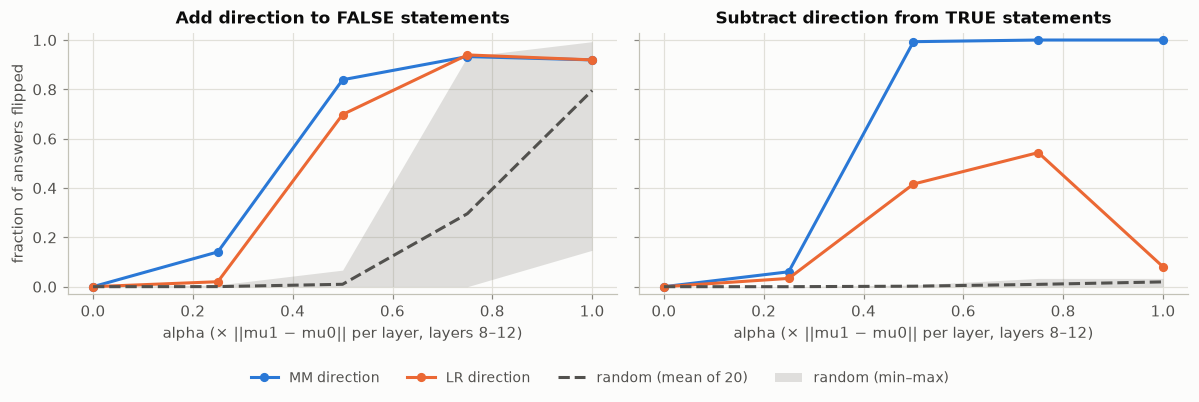

In [9]:
ALPHAS = [0.25, 0.5, 0.75, 1.0]
curve = []
for a in ALPHAS:
    for name, u in [("MM", u_mm), ("LR", u_lr)]:
        r = {"add": run(u, a), "sub": run(u, -a)}
        row = summarize(r, name)
        curve.append({"alpha": a, "direction": name, "flip F→T": row["F→T flip rate"], "flip T→F": row["T→F flip rate"],
                      "mean m false (add)": row["F→T: mean m on false (add)"], "mean m true (sub)": row["T→F: mean m on true (subtract)"],
                      "P(T)+P(F)": row["P(T)+P(F)"]})
    rd = rand1 if a == 1.0 else random_effects(a)
    curve.append({"alpha": a, "direction": "random (mean of 20)", "flip F→T": rd["flip F→T"].mean(), "flip T→F": rd["flip T→F"].mean(),
                  "mean m false (add)": rd["mean m on false"].mean(), "mean m true (sub)": rd["mean m on true"].mean(),
                  "P(T)+P(F)": rd["P(T)+P(F)"].mean(),
                  "random F→T min": rd["flip F→T"].min(), "random F→T max": rd["flip F→T"].max(),
                  "random T→F min": rd["flip T→F"].min(), "random T→F max": rd["flip T→F"].max()})
curve = pd.DataFrame(curve)
display(curve[["alpha", "direction", "flip F→T", "flip T→F", "mean m false (add)", "mean m true (sub)", "P(T)+P(F)"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, col, title in [(axes[0], "flip F→T", "Add direction to FALSE statements"), (axes[1], "flip T→F", "Subtract direction from TRUE statements")]:
    for name, color in [("MM", pl.C_TRUE), ("LR", pl.C_FALSE)]:
        part = curve[curve.direction == name]
        ax.plot([0] + ALPHAS, [0] + list(part[col]), marker="o", ms=5, color=color, label=f"{name} direction")
    rnd = curve[curve.direction.str.startswith("random")]
    ax.plot([0] + ALPHAS, [0] + list(rnd[col]), color=pl.INK2, ls="--", label="random (mean of 20)")
    ax.fill_between([0] + ALPHAS, [0] + list(rnd[f"random {col.split()[1]} min"]), [0] + list(rnd[f"random {col.split()[1]} max"]),
                    color=pl.MUTED, alpha=0.25, lw=0, label="random (min–max)")
    ax.set(title=title, xlabel="alpha (× ||mu1 − mu0|| per layer, layers 8–12)", ylim=(-0.03, 1.03))
axes[0].set_ylabel("fraction of answers flipped")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

#### Cell 08 · 개입 크기 vs activation 크기

- **이번 셀의 질문:** layer 8–12에 누적해 더한 벡터는 원래 residual에 비해 얼마나 큰가?
- **출력에서 볼 것:** 마침표 위치 residual norm(저장된 출력: layer 8에서 약 5.7, layer 12에서 약 8.3)과, layer 12 출력 시점에 누적된 개입 크기(α × 4.5 × 5층)를 비교한다.
- **해석 범위:** α=1이면 누적 크기(약 22)가 원래 residual norm의 2.5배를 넘는다. 이런 activation은 모델이 자연스럽게 만나는 분포 밖일 가능성이 크고, 그곳에서는 '무엇을 밀었는가'보다 '많이 밀었다'가 결과를 지배할 수 있다. α=0.5(누적 약 11)도 작지 않다.
- **다음 단계의 목적:** MM과 LR의 차이를 ①의 toy와 연결하고, 개입 위치(층)의 역할을 본다.

In [10]:
norms = {l: float(np.linalg.norm(store.dataset("cities", [l])[l], axis=1).mean()) for l in INTERVENE_LAYERS}
print("mean ||h|| at period token:", {l: round(v, 2) for l, v in norms.items()})
for a in [0.25, 0.5, 1.0]:
    print(f"alpha={a}: per-layer add {a * SCALE:.2f}, cumulative by layer {PROBE_LAYER} ≈ {a * SCALE * len(INTERVENE_LAYERS):.1f}")

mean ||h|| at period token: {8: 5.72, 9: 6.37, 10: 6.45, 11: 6.84, 12: 8.32}
alpha=0.25: per-layer add 1.12, cumulative by layer 12 ≈ 5.6
alpha=0.5: per-layer add 2.24, cumulative by layer 12 ≈ 11.2
alpha=1.0: per-layer add 4.49, cumulative by layer 12 ≈ 22.4


# 5️⃣ 왜 MM은 되고 LR은 약한가, 그리고 "어디에" 더하는가

**MM vs LR.** 같은 층에서 두 방향의 cosine은 0.49다. 분류 성능은 둘 다 test AUROC 1.000이지만 개입 효과는, 특히 빼기(T→F)에서 MM이 훨씬 크다(α=0.5: 99% vs 42%). ①의 toy를 떠올리면 이유가 그려진다. LR은 class 내부 잡음을 상쇄하도록 기울어진 **판별 방향**이고, MM은 두 class가 실제로 **떨어져 있는 방향**이다. 모델이 참/거짓 정보를 평균 차이 방향으로 싣고 있다면, 그 방향으로 미는 쪽이 판단을 바꾼다. Marks & Tegmark도 LLaMA-2-13B에서 같은 차이를 보고했다(MM .85/.97 vs LR .33/.52).

**어디에 더하는가.** 아래 셀은 개입하는 층의 띠를 옮기고(4–8, 8–12, 12–16), 같은 **총량**(α=0.5 × 5층 = 2.5배)을 한 층에 몰아서도 더한다. 조건마다 무작위 방향 5개를 같은 크기로 더해 특이성을 확인한다.

#### Cell 09 · 층 띠 옮기기와 한 층 몰아 더하기

- **이번 셀의 질문:** layer 12에서 찾은 방향은 어느 층에 더해야 판단을 바꾸는가?
- **출력에서 볼 것:** 저장된 출력: 띠 4–8은 95%/100%, 8–12는 84%/99%인데 **12–16은 3%/0%** 다. 같은 총량을 layer 8 한 곳에 몰면 89%/100%, layer 12 한 곳에 몰면 28%/9%다. 무작위 방향은 모든 조건에서 0–5%다.
- **해석 범위:** probe가 **가장 잘 읽히는 층**(12)과 **개입이 판단을 바꾸는 층**(4–12)이 다르다. layer 12 이후 문장 끝 위치를 바꿔도 판단이 거의 바뀌지 않는다는 것은, 그 무렵에는 판단에 필요한 정보가 이미 뒤쪽 위치(`This statement is:`)로 옮겨졌다는 해석과 맞는다(정보가 위치를 따라 이동한다). 이 해석은 ⑦의 제거 실험에서 직접 검사한다.
- **다음 단계의 목적:** 주장 장부를 갱신한다.

In [11]:
where_rows = []
for name, layers, alpha in [("layers 4–8, α=0.5 each", list(range(4, 9)), 0.5),
                            ("layers 8–12, α=0.5 each", INTERVENE_LAYERS, 0.5),
                            ("layers 12–16, α=0.5 each", list(range(12, 17)), 0.5),
                            ("layer 8 only, α=2.5", [8], 2.5),
                            (f"layer {PROBE_LAYER} only, α=2.5", [PROBE_LAYER], 2.5)]:
    r = {"add": run(u_mm, alpha, layers), "sub": run(u_mm, -alpha, layers)}
    row = summarize(r, name)
    rand = [run(v, alpha, layers) for v in RANDOM_DIRS[:5]]
    where_rows.append({"intervention": name, "MM flip F→T": row["F→T flip rate"], "MM flip T→F": row["T→F flip rate"],
                       "random flip F→T (mean of 5)": float(np.mean([np.mean(q["p_diff"][y_test == 0] > 0) for q in rand])),
                       "random flip T→F (mean of 5)": float(np.mean([np.mean(q["p_diff"][y_test == 1] < 0) for q in rand])),
                       "P(T)+P(F)": row["P(T)+P(F)"]})
where = pd.DataFrame(where_rows)
display(where)

,intervention,MM flip F→T,MM flip T→F,random flip F→T (mean of 5),random flip T→F (mean of 5),P(T)+P(F)
0,"layers 4–8, α=0.5 each",0.946,1.000,0.048,0.032,0.996
1,"layers 8–12, α=0.5 each",0.839,0.993,0.004,0.003,0.993
2,"layers 12–16, α=0.5 each",0.027,0.000,0.000,0.000,0.997
3,"layer 8 only, α=2.5",0.886,1.000,0.019,0.009,0.993
4,"layer 12 only, α=2.5",0.275,0.087,0.004,0.000,0.995


### 여기까지의 결론

- GoT 설정(α=1)을 그대로 쓰면 MM 방향은 양방향 판단을 크게 뒤집는다. 그러나 **같은 크기의 무작위 방향도 F→T를 상당히 일으킨다.** α=1의 F→T 결과만으로는 "진실 방향"을 주장할 수 없다.
- α를 줄이면(0.25–0.5) MM 방향은 양방향 모두 판단을 뒤집고, 무작위 방향은 거의 아무것도 하지 않는다. **이 구간의 결과가 인과 주장의 근거다.**
- 같은 분류 성능의 LR 방향은 특히 빼기(T→F)에서 효과가 훨씬 약하다. "잘 분류하는 방향"과 "모델이 쓰는 방향"은 다를 수 있다.
- layer 12의 방향을 layer 12 **이후**에 더하면 거의 효과가 없고, 그 **이전**(4–12)에 더해야 판단이 바뀐다. 가장 잘 읽히는 곳과 개입이 통하는 곳은 다르다.

## 주장 장부 — ④의 갱신

| ID | 주장 | 근거 | 아직 배제하지 못한 설명 | 상태 |
|---|---|---|---|---|
| C1–C3 | (①~③) | | | 지지됨 |
| C4 | layer 12 MM 진실 방향은 모델의 TRUE/FALSE 판단에 **인과적으로 관여**한다: layer 8–12의 문장 끝 위치에서 이 방향으로 밀면 판단이 양방향으로 뒤집히고(α=0.5: 84%, 99%), 같은 크기의 무작위 방향은 그렇지 않다(1%, 0.2%). | ④ 용량–반응, 무작위 20개 대조, 양방향, P(T)+P(F) 유지, 층 띠 비교 | 분포 밖 activation(누적 크기), 단일 prompt 형식, **필요성 미검증**(없애면 못 하는가?), 부분공간 개입의 착시(Makelov et al. 2023) | **지지됨 (충분성)** |

C4는 "밀면 바뀐다"(충분성)이다. "그 정보가 없으면 판단할 수 없다"(필요성)는 아직이다. ⑦에서 제거 실험으로 묻는다.

#### Cell 10 · 결과 저장

- **이번 셀의 질문:** ⑤가 모아 읽을 개입 수치를 기록한다.
- **출력에서 볼 것:** `results/04_causal.json` 경로가 출력된다.
- **해석 범위:** 용량–반응 표와 위치 비교 표를 저장한다.
- **다음 단계의 목적:** ⑤ 논문 초안 — 1부의 증거로 초록을 쓴다.

In [12]:
pl.save_results("04_causal", {
    "probe_layer": PROBE_LAYER,
    "intervene_layers": INTERVENE_LAYERS,
    "scale_norm_mu_diff": SCALE,
    "baseline": {"mean_m_true": float(base["p_diff"][y_test == 1].mean()), "mean_m_false": float(base["p_diff"][y_test == 0].mean())},
    "got_alpha1": summarize(got, "MM α=1"),
    "random_alpha1": rand1.describe().loc[["mean", "min", "max"]].to_dict(),
    "dose_response": curve.to_dict(orient="records"),
    "where": where.to_dict(orient="records"),
    "residual_norms": norms,
    "claims": [{"id": "C4", "status": "지지됨 (충분성)",
                "text": "L8–12 문장 끝에서 MM 진실 방향으로 밀면 판단이 양방향으로 뒤집히고(α=0.5: F→T 84%, T→F 99%) 같은 크기의 무작위 방향은 그렇지 않다(1%, 0.2%). α=1에서는 F→T가 비특이적(무작위 평균 80%). L12 이후 층에 더하면 효과가 거의 없다."}],
})

PosixPath('/workspace/ARENA_3.0/chapter1_transformer_interp/exercises/part31_linear_probes_ko/results/04_causal.json')